# Homework 3

Датасет тот же, что в первых двух работах: [TMDB 5000](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata).

В качестве временного ряда беру среднюю оценку фильмов `vote_average` по месяцам. Признаки множественной регрессии: средняя длительность, популярность, бюджет и число вышедших фильмов. Используются последние 200 последовательных месяцев: 160 (80 %) для обучения и 40 (20 %) для проверки. Так результаты сопоставимы с Homework 2.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, log_loss, mean_absolute_error, mean_squared_error,
    roc_auc_score, roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

movies = pd.read_csv("tmdb_5000_movies.csv")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies = movies.dropna(subset=["release_date"])
movies["month"] = movies["release_date"].dt.to_period("M")

g = movies.groupby("month").agg(
    y=("vote_average", "mean"),
    runtime=("runtime", "mean"),
    popularity=("popularity", "mean"),
    budget=("budget", "mean"),
    n=("id", "count"),
)

# Непрерывная календарная сетка, как в Homework 2.
g = g.reindex(pd.period_range("1987-01", g.index.max(), freq="M"))
for col in ["y", "runtime", "popularity", "budget"]:
    g[col] = g[col].ffill().bfill()
g["n"] = g["n"].fillna(0)

ts = g.iloc[-200:].copy()
features = ["runtime", "popularity", "budget", "n"]
n_train = 160
X = ts[features].to_numpy()
y = ts["y"].to_numpy()
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]
dates = ts.index.to_timestamp()

print("всего месяцев:", len(ts))
print("train:", len(y_train), "test:", len(y_test))
print("период:", ts.index.min(), "—", ts.index.max())
ts.head().round(3)

всего месяцев: 200
train: 160 test: 40
период: 2000-07 — 2017-02


,y,runtime,popularity,budget,n
2000-07,5.736,106.182,10.616,4.227273e+07,11.0
2000-08,6.092,106.667,13.232,2.750000e+07,12.0
2000-09,6.109,106.091,10.390,1.252273e+07,22.0
2000-10,6.041,105.118,13.780,2.600588e+07,17.0
2000-11,6.100,109.778,23.274,7.005556e+07,9.0


## 1. Множественная регрессия

По заданию нужны не менее двух ранее использованных методов. Беру ровно два: **МНК** и **SVR**. В обеих моделях используются одни и те же четыре признака: `runtime`, `popularity`, `budget`, `n`. Для SVR масштабирование настраивается только по обучающей выборке.

In [2]:
regressors = {
    "МНК": LinearRegression(),
    "SVR": make_pipeline(StandardScaler(), SVR(kernel="rbf", C=1.0, epsilon=0.1)),
}

reg_predictions = {}
for name, model in regressors.items():
    model.fit(X_train, y_train)
    reg_predictions[name] = np.asarray(model.predict(X_test)).ravel()

pd.DataFrame(
    {"реальное значение": y_test, **reg_predictions},
    index=dates[n_train:],
).head(10).round(3)

,реальное значение,МНК,SVR
2013-11-01,6.329,6.279,6.406
2013-12-01,6.221,6.334,6.356
2014-01-01,4.718,5.785,5.894
2014-02-01,6.136,6.177,6.400
2014-03-01,5.556,5.995,5.790
2014-04-01,5.317,5.853,5.817
2014-05-01,5.942,6.067,5.879
2014-06-01,4.910,6.199,6.071
2014-07-01,5.731,6.699,6.151
2014-08-01,5.721,6.293,6.211


## 2. Проверка адекватности регрессионных моделей

MAE и RMSE измеряются в пунктах рейтинга. MAPE показывает среднюю относительную ошибку в процентах. MASE делит MAE модели на среднюю ошибку наивного прогноза «следующий месяц равен предыдущему», рассчитанную по train; значение меньше 1 означает преимущество над этим прогнозом.

In [3]:
mase_scale = np.mean(np.abs(np.diff(y_train)))

def regression_scores(real, prediction):
    return {
        "MAE": mean_absolute_error(real, prediction),
        "RMSE": mean_squared_error(real, prediction) ** 0.5,
        "MAPE, %": np.mean(np.abs((real - prediction) / real)) * 100,
        "MASE": mean_absolute_error(real, prediction) / mase_scale,
    }

regression_table = pd.DataFrame({
    name: regression_scores(y_test, prediction)
    for name, prediction in reg_predictions.items()
}).T.sort_values("RMSE")

display(regression_table.round(4))
best_regression = regression_table["RMSE"].idxmin()
print("лучшая модель по RMSE:", best_regression)
print("её MASE:", round(regression_table.loc[best_regression, "MASE"], 3))

,MAE,RMSE,"MAPE, %",MASE
SVR,0.5461,0.6654,9.6654,1.6447
МНК,0.7144,0.8582,12.3789,2.1515


лучшая модель по RMSE: SVR
её MASE: 1.645


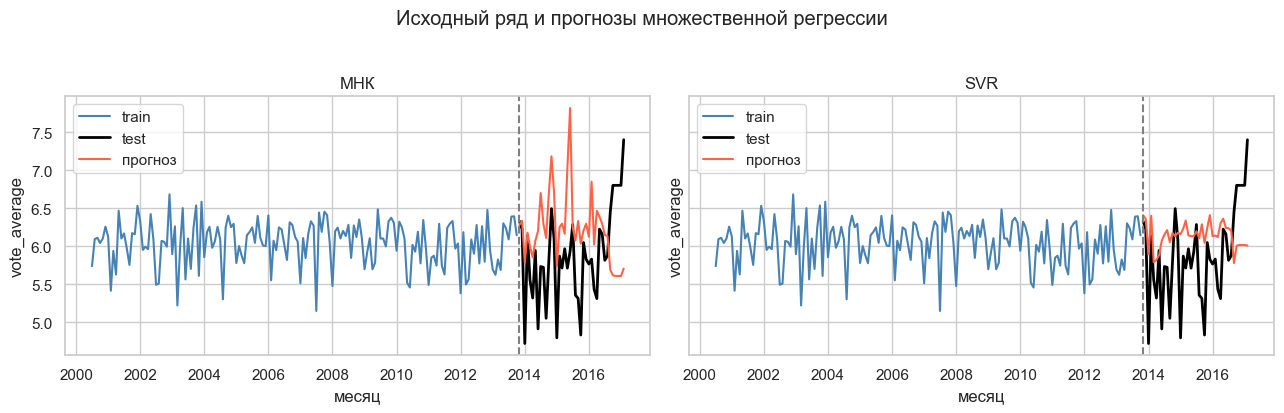

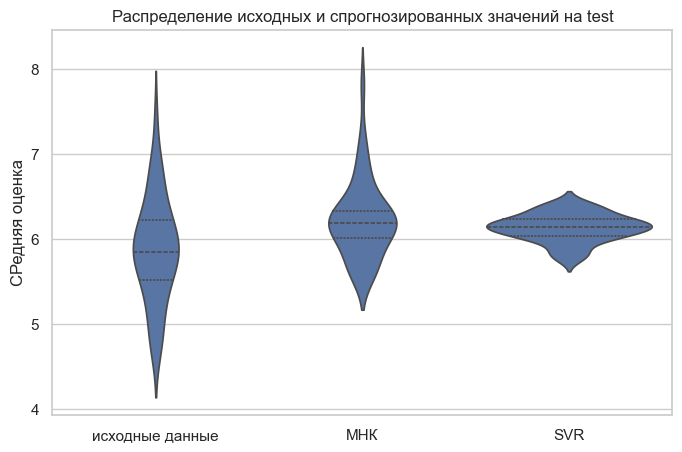

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for ax, (name, prediction) in zip(axes, reg_predictions.items()):
    ax.plot(dates[:n_train], y_train, label="train", color="steelblue")
    ax.plot(dates[n_train:], y_test, label="test", color="black", linewidth=2)
    ax.plot(dates[n_train:], prediction, label="прогноз", color="tomato")
    ax.axvline(dates[n_train], color="gray", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("месяц")
    ax.set_ylabel("vote_average")
    ax.legend()
fig.suptitle("Исходный ряд и прогнозы множественной регрессии", y=1.03)
plt.tight_layout()
plt.show()

violin_data = pd.DataFrame({
    "исходные данные": y_test,
    **reg_predictions,
}).melt(var_name="ряд", value_name="vote_average")

plt.figure(figsize=(8, 5))
sns.violinplot(data=violin_data, x="ряд", y="vote_average", inner="quartile")
plt.xlabel("")
plt.ylabel("vote_average")
plt.title("Распределение исходных и спрогнозированных значений на test")
plt.show()

Графики позволяют проверить, сохраняют ли модели уровень и разброс ряда. Численно лучшей считаю модель с минимальным RMSE; MAE, MAPE и MASE использую как дополнительную проверку. Если прогнозная «скрипка» заметно уже исходной, модель сглаживает месячные колебания.

## 3. Переход к задаче классификации

Для временного ряда класс равен 1, если средняя оценка выросла относительно предыдущего месяца, и 0 — если не выросла. В признаки добавляется известное значение предыдущего месяца `previous_y`. После `diff` остаётся 199 объектов: первые 159 относятся к train, последние 40 — к тому же тестовому периоду, что и в регрессии.

,train,test
0 — нет роста,84,23
1 — рост,75,17


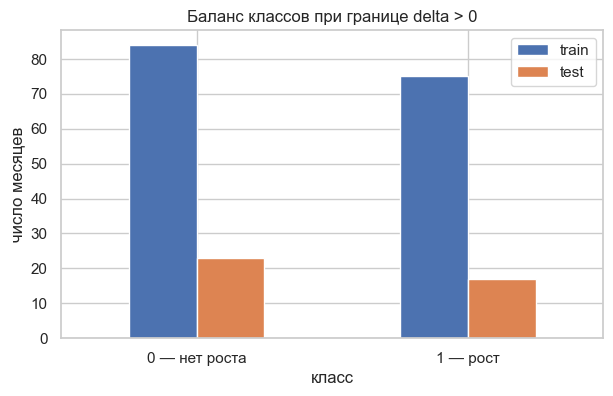

доли классов train: {0: 0.528, 1: 0.472}


In [5]:
classification_data = ts.copy()
classification_data["previous_y"] = classification_data["y"].shift(1)
classification_data["delta"] = classification_data["y"] - classification_data["previous_y"]
classification_data["growth"] = (classification_data["delta"] > 0).astype(int)
classification_data = classification_data.dropna().copy()

classification_features = features + ["previous_y"]
X_class = classification_data[classification_features].to_numpy()
y_class = classification_data["growth"].to_numpy()
n_class_train = len(classification_data) - len(y_test)
X_class_train, X_class_test = X_class[:n_class_train], X_class[n_class_train:]
y_class_train, y_class_test = y_class[:n_class_train], y_class[n_class_train:]

balance = pd.DataFrame({
    "train": pd.Series(y_class_train).value_counts().sort_index(),
    "test": pd.Series(y_class_test).value_counts().sort_index(),
}).fillna(0).astype(int)
balance.index = ["0 — нет роста", "1 — рост"]
display(balance)

balance.plot(kind="bar", figsize=(7, 4), rot=0)
plt.xlabel("класс")
plt.ylabel("число месяцев")
plt.title("Баланс классов при границе delta > 0")
plt.show()

share = pd.Series(y_class_train).value_counts(normalize=True).sort_index()
print("доли классов train:", share.round(3).to_dict())

## 4. kNN, SVM и два дополнительных классификатора

Обязательные методы — kNN и SVM. Для дополнительных двух баллов добавлены Logistic Regression и дерево CART. Accuracy показывает долю правильных ответов, F-мера учитывает одновременно precision и recall, LogLoss оценивает качество вероятностей, ROC-AUC — качество ранжирования классов.

In [6]:
classifiers = {
    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7, weights="distance")),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "CART": DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE),
}

def classification_scores(real, labels, probabilities):
    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)
    return {
        "Accuracy": accuracy_score(real, labels),
        "F1": f1_score(real, labels, zero_division=0),
        "LogLoss": log_loss(real, probabilities, labels=[0, 1]),
        "ROC-AUC": roc_auc_score(real, probabilities),
    }

class_predictions = {}
class_probabilities = {}
for name, model in classifiers.items():
    model.fit(X_class_train, y_class_train)
    class_predictions[name] = model.predict(X_class_test)
    class_probabilities[name] = model.predict_proba(X_class_test)[:, 1]

classification_table = pd.DataFrame({
    name: classification_scores(y_class_test, class_predictions[name], class_probabilities[name])
    for name in classifiers
}).T.sort_values(["F1", "Accuracy"], ascending=False)

display(classification_table.round(4))
best_classifier = classification_table.index[0]
print("лучшая самостоятельная модель по F1:", best_classifier)

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.600,0.6364,3.2344,0.6317
SVM,0.525,0.6275,0.9059,0.5320
Logistic Regression,0.575,0.6222,1.2799,0.7647
CART,0.550,0.5909,3.9402,0.5691


лучшая самостоятельная модель по F1: kNN


## 5. Классы из лучшей регрессионной модели

Прогноз роста получается сравнением прогноза лучшей регрессии с реальным значением предыдущего месяца. Для LogLoss и ROC непрерывная разность переводится в вероятность сигмоидой; масштаб берётся из стандартного отклонения месячных изменений только на train. Граница вероятности 0.5 точно соответствует условию «прогноз выше предыдущего значения».

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.600,0.6364,3.2344,0.6317
SVM,0.525,0.6275,0.9059,0.5320
Logistic Regression,0.575,0.6222,1.2799,0.7647
Регрессия: SVR,0.525,0.5957,0.7206,0.7289
CART,0.550,0.5909,3.9402,0.5691


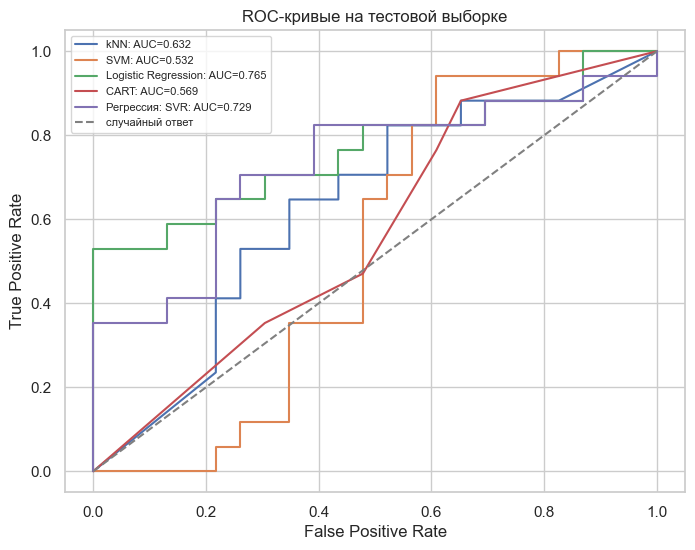

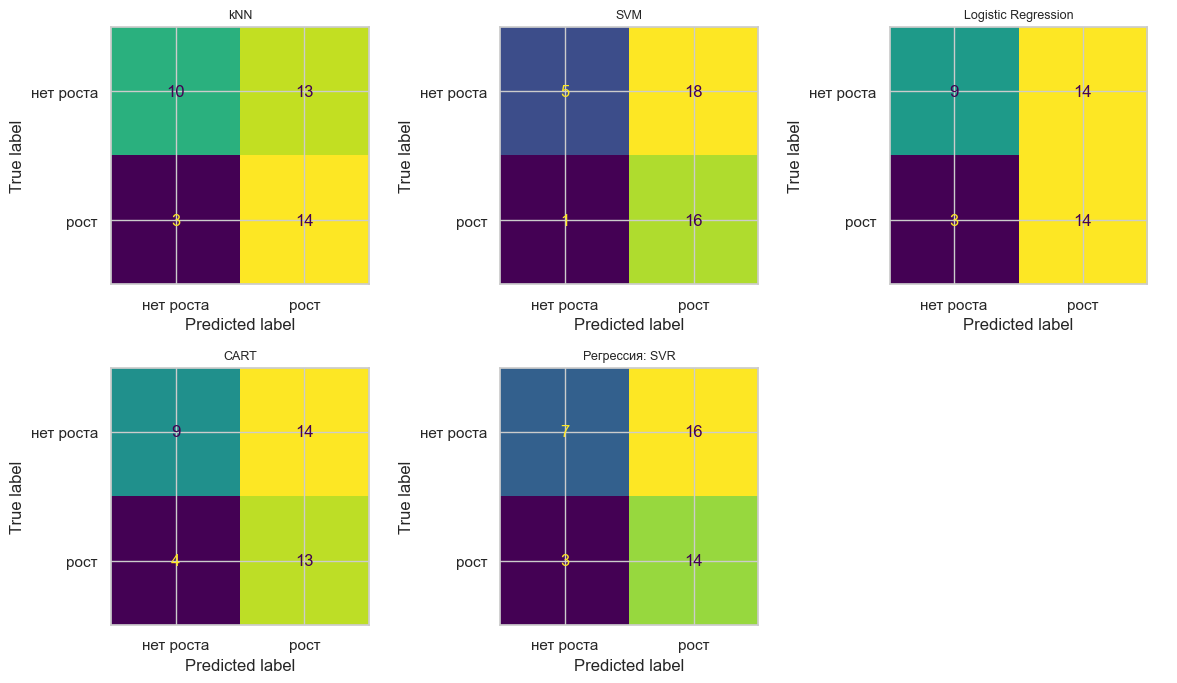

In [7]:
previous_y_test = classification_data["previous_y"].to_numpy()[n_class_train:]
best_reg_prediction = reg_predictions[best_regression]
regression_margin = best_reg_prediction - previous_y_test
margin_scale = classification_data["delta"].to_numpy()[:n_class_train].std()
regression_probability = 1 / (1 + np.exp(-regression_margin / margin_scale))
regression_class = (best_reg_prediction > previous_y_test).astype(int)

class_predictions[f"Регрессия: {best_regression}"] = regression_class
class_probabilities[f"Регрессия: {best_regression}"] = regression_probability

all_classification_table = pd.DataFrame({
    name: classification_scores(y_class_test, class_predictions[name], class_probabilities[name])
    for name in class_predictions
}).T.sort_values(["F1", "Accuracy"], ascending=False)
display(all_classification_table.round(4))

plt.figure(figsize=(8, 6))
for name, probabilities in class_probabilities.items():
    fpr, tpr, _ = roc_curve(y_class_test, probabilities)
    auc = roc_auc_score(y_class_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name}: AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="случайный ответ")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые на тестовой выборке")
plt.legend(fontsize=8)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (name, labels) in zip(axes.ravel(), class_predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_class_test, labels),
        display_labels=["нет роста", "рост"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
for ax in axes.ravel()[len(class_predictions):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Дополнительная часть: изменение границы классов

При исходном правиле классы уже достаточно близки по размеру. Чтобы сделать train почти точно сбалансированным, меняю границу: класс 1 теперь означает изменение выше медианы `delta` на обучающей выборке. Медиана и все преобразования определяются без использования test. Затем все четыре классификатора обучаются повторно, а их Accuracy сравнивается с исходной постановкой.

In [8]:
delta = classification_data["delta"].to_numpy()
balance_border = np.median(delta[:n_class_train])
y_balanced = (delta > balance_border).astype(int)
y_balanced_train = y_balanced[:n_class_train]
y_balanced_test = y_balanced[n_class_train:]

new_balance = pd.DataFrame({
    "исходная граница": pd.Series(y_class_train).value_counts().sort_index(),
    "граница по медиане": pd.Series(y_balanced_train).value_counts().sort_index(),
}).fillna(0).astype(int)
new_balance.index = ["класс 0", "класс 1"]
display(new_balance)
print("новая граница delta >", round(balance_border, 4))

balanced_predictions = {}
balanced_probabilities = {}
for name, prototype in classifiers.items():
    model = clone(prototype)
    model.fit(X_class_train, y_balanced_train)
    balanced_predictions[name] = model.predict(X_class_test)
    balanced_probabilities[name] = model.predict_proba(X_class_test)[:, 1]

balanced_table = pd.DataFrame({
    name: classification_scores(
        y_balanced_test, balanced_predictions[name], balanced_probabilities[name]
    )
    for name in classifiers
}).T.sort_values(["F1", "Accuracy"], ascending=False)
display(balanced_table.round(4))

accuracy_comparison = pd.DataFrame({
    "исходная граница delta > 0": classification_table["Accuracy"],
    "сбалансированная граница": balanced_table["Accuracy"],
})
accuracy_comparison["изменение"] = (
    accuracy_comparison["сбалансированная граница"]
    - accuracy_comparison["исходная граница delta > 0"]
)
display(accuracy_comparison.sort_values("сбалансированная граница", ascending=False).round(4))

,исходная граница,граница по медиане
класс 0,84,80
класс 1,75,79


новая граница delta > -0.0294


,Accuracy,F1,LogLoss,ROC-AUC
SVM,0.65,0.7407,0.8857,0.4762
kNN,0.55,0.6250,4.7779,0.4825
CART,0.55,0.6087,5.2442,0.4511
Logistic Regression,0.50,0.6000,1.6858,0.6266


,исходная граница delta > 0,сбалансированная граница,изменение
SVM,0.525,0.65,0.125
CART,0.550,0.55,0.000
kNN,0.600,0.55,-0.050
Logistic Regression,0.575,0.50,-0.075


## Выводы по полученным значениям

In [9]:
best_standalone_f1 = classification_table["F1"].idxmax()
best_all_f1 = all_classification_table["F1"].idxmax()
best_auc = all_classification_table["ROC-AUC"].idxmax()
best_balanced = balanced_table["F1"].idxmax()

print(
    f"1. Среди регрессий лучшая — {best_regression}: "
    f"RMSE={regression_table.loc[best_regression, 'RMSE']:.3f}, "
    f"MAE={regression_table.loc[best_regression, 'MAE']:.3f}, "
    f"MAPE={regression_table.loc[best_regression, 'MAPE, %']:.2f}%, "
    f"MASE={regression_table.loc[best_regression, 'MASE']:.3f}."
)
if regression_table.loc[best_regression, "MASE"] < 1:
    print("   MASE < 1: модель лучше наивного прогноза предыдущим значением.")
else:
    print("   MASE > 1: среди проверенных регрессий это лучший результат, но наивный прогноз предыдущим значением точнее.")

print(
    f"2. Среди самостоятельных классификаторов максимальная F1 у {best_standalone_f1} "
    f"(F1={classification_table.loc[best_standalone_f1, 'F1']:.3f}, "
    f"Accuracy={classification_table.loc[best_standalone_f1, 'Accuracy']:.3f})."
)
print(
    f"3. При сравнении со способом через регрессию максимальная F1 у {best_all_f1} "
    f"(F1={all_classification_table.loc[best_all_f1, 'F1']:.3f}, "
    f"Accuracy={all_classification_table.loc[best_all_f1, 'Accuracy']:.3f}); "
    f"лучший ROC-AUC у {best_auc} ({all_classification_table.loc[best_auc, 'ROC-AUC']:.3f})."
)
print(
    f"4. После почти точной балансировки классов лучшая F1 у {best_balanced}: "
    f"F1={balanced_table.loc[best_balanced, 'F1']:.3f}, "
    f"Accuracy={balanced_table.loc[best_balanced, 'Accuracy']:.3f}."
)
print("   Accuracy SVM изменилась на", round(accuracy_comparison.loc["SVM", "изменение"], 3),
      "; изменение границы заметно влияет на итог и на смысл положительного класса.")

1. Среди регрессий лучшая — SVR: RMSE=0.665, MAE=0.546, MAPE=9.67%, MASE=1.645.
   MASE > 1: среди проверенных регрессий это лучший результат, но наивный прогноз предыдущим значением точнее.
2. Среди самостоятельных классификаторов максимальная F1 у kNN (F1=0.636, Accuracy=0.600).
3. При сравнении со способом через регрессию максимальная F1 у kNN (F1=0.636, Accuracy=0.600); лучший ROC-AUC у Logistic Regression (0.765).
4. После почти точной балансировки классов лучшая F1 у SVM: F1=0.741, Accuracy=0.650.
   Accuracy SVM изменилась на 0.125 ; изменение границы заметно влияет на итог и на смысл положительного класса.


## Итог

В работе построены две требуемые множественные регрессионные модели — МНК и SVR — и проверены графиками, скрипичными диаграммами и метриками MAE, RMSE, MAPE, MASE. Затем ряд сведён к классификации направления изменения. Сравнены обязательные kNN и SVM, два дополнительных метода Logistic Regression и CART, а также классы, полученные из лучшей регрессии. Для них рассчитаны Accuracy, F1, LogLoss, ROC-AUC, построены ROC-кривые и confusion matrix. Дополнительно проверена сбалансированность классов и повторено решение после изменения границы.

Окончательный выбор регрессии делается по минимальному RMSE, а классификатора — прежде всего по F1 и ROC-AUC. Accuracy рассматривается вместе с балансом классов, потому что сама по себе она может быть завышена преобладающим классом.